In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc

In [2]:
file1 = "energy_data.csv"
file2 = "weather_data.csv"
edf = pd.read_csv(file1)
wdf = pd.read_csv(file2)
# print(edf.head())
# print(wdf.head())

In [3]:
# print(edf.dtypes)
# print(wdf.dtypes)

In [23]:
edf.info()
display(edf.describe())
wdf.info()
display(wdf.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date & Time                      17520 non-null  datetime64[ns]
 1   use [kW]                         17520 non-null  float64       
 2   gen [kW]                         17520 non-null  float64       
 3   Grid [kW]                        17520 non-null  float64       
 4   AC [kW]                          17520 non-null  float64       
 5   Furnace [kW]                     17520 non-null  float64       
 6   Cellar Lights [kW]               17520 non-null  float64       
 7   Washer [kW]                      17520 non-null  float64       
 8   First Floor lights [kW]          17520 non-null  float64       
 9   Utility Rm + Basement Bath [kW]  17520 non-null  float64       
 10  Garage outlets [kW]              17520 non-null  float64  

,Date & Time,use [kW],gen [kW],Grid [kW],AC [kW],Furnace [kW],Cellar Lights [kW],Washer [kW],First Floor lights [kW],Utility Rm + Basement Bath [kW],Garage outlets [kW],MBed + KBed outlets [kW],Dryer + egauge [kW],Panel GFI (central vac) [kW],Home Office (R) [kW],Dining room (R) [kW],Microwave (R) [kW],Fridge (R) [kW],hour,month
count,17520,17520.000000,17520.0,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,1.752000e+04,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,2014-07-02 12:24:06.986301440,0.662905,0.0,0.662905,0.088999,0.085888,0.011036,0.003067,0.015852,0.005105,0.005949,4.602680e-02,0.069099,0.005005,0.053700,0.004186,0.015237,0.073561,11.499886,6.526941
min,2014-01-01 00:00:00,0.011083,0.0,0.011083,0.000000,0.000117,0.000083,0.000000,0.000350,0.000017,0.000050,5.560000e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2014-04-02 06:52:30,0.314125,0.0,0.314125,0.000030,0.009340,0.005414,0.000099,0.003630,0.002388,0.004841,2.116667e-03,0.000030,0.000298,0.003468,0.001346,0.004153,0.006558,5.750000,4.000000
50%,2014-07-02 12:45:00,0.468725,0.0,0.468725,0.000069,0.009704,0.005881,0.000219,0.003718,0.003737,0.004928,3.109528e-02,0.000058,0.006979,0.072627,0.003882,0.004624,0.070129,11.500000,7.000000
75%,2014-10-01 18:37:30,0.700617,0.0,0.700617,0.000707,0.143531,0.007042,0.000333,0.015980,0.003876,0.005001,6.671972e-02,0.000096,0.007175,0.077099,0.004446,0.004877,0.129642,17.250000,10.000000
max,2014-12-31 23:30:00,6.833205,0.0,6.833205,3.687768,0.437212,0.146692,0.819167,0.423816,0.476571,0.047370,1.514727e+00,4.287879,0.366653,0.211308,0.074872,1.701807,0.410929,23.000000,12.000000
std,NaN,0.678399,0.0,0.678399,0.438887,0.129054,0.013123,0.020444,0.030792,0.020500,0.003621,7.525857e-02,0.430429,0.007543,0.037668,0.005455,0.066807,0.062182,6.922549,3.448075


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   temperature        8760 non-null   float64       
 1   icon               8760 non-null   object        
 2   humidity           8760 non-null   float64       
 3   visibility         8760 non-null   float64       
 4   summary            8760 non-null   object        
 5   pressure           8760 non-null   float64       
 6   windSpeed          8760 non-null   float64       
 7   cloudCover         7290 non-null   float64       
 8   time               8760 non-null   int64         
 9   windBearing        8760 non-null   int64         
 10  precipIntensity    8760 non-null   float64       
 11  dewPoint           8760 non-null   float64       
 12  precipProbability  8760 non-null   float64       
 13  datetime           8760 non-null   datetime64[ns]
 14  date    

,temperature,humidity,visibility,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,datetime
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,7290.000000,8.760000e+03,8760.00000,8760.000000,8760.000000,8760.000000,8760
mean,48.062076,0.682888,9.025791,1016.450749,6.534568,0.137971,1.404301e+09,204.46347,0.003761,37.072056,0.066771,2014-07-02 11:30:00
min,-10.070000,0.140000,0.320000,979.980000,0.030000,0.000000,1.388534e+09,0.00000,0.000000,-15.870000,0.000000,2014-01-01 00:00:00
25%,33.165000,0.530000,9.040000,1011.530000,3.630000,0.000000,1.396418e+09,150.00000,0.000000,23.425000,0.000000,2014-04-02 05:45:00
50%,49.220000,0.710000,9.970000,1016.430000,5.850000,0.060000,1.404301e+09,210.00000,0.000000,38.510000,0.000000,2014-07-02 11:30:00
75%,63.832500,0.860000,10.000000,1021.310000,8.692500,0.200000,1.412184e+09,297.00000,0.000000,54.302500,0.000000,2014-10-01 17:15:00
max,89.460000,0.960000,10.000000,1042.400000,24.750000,1.000000,1.420067e+09,359.00000,0.355700,72.880000,0.870000,2014-12-31 23:00:00
std,19.694743,0.188763,1.859263,7.903670,3.884500,0.212384,9.104179e+06,106.57823,0.015565,20.257221,0.183459,NaN


In [5]:
print(edf.isnull().sum())
print(wdf.isnull().sum())

Date & Time                        0
use [kW]                           0
gen [kW]                           0
Grid [kW]                          0
AC [kW]                            0
Furnace [kW]                       0
Cellar Lights [kW]                 0
Washer [kW]                        0
First Floor lights [kW]            0
Utility Rm + Basement Bath [kW]    0
Garage outlets [kW]                0
MBed + KBed outlets [kW]           0
Dryer + egauge [kW]                0
Panel GFI (central vac) [kW]       0
Home Office (R) [kW]               0
Dining room (R) [kW]               0
Microwave (R) [kW]                 0
Fridge (R) [kW]                    0
dtype: int64
temperature             0
icon                    0
humidity                0
visibility              0
summary                 0
pressure                0
windSpeed               0
cloudCover           1470
time                    0
windBearing             0
precipIntensity         0
dewPoint                0
precipPro

In [6]:
# Parse Date & Time in edf and extract the date
edf["Date & Time"] = pd.to_datetime(edf["Date & Time"])
edf["date"] = edf["Date & Time"].dt.date
daily_energy = edf.groupby("date")["use [kW]"].sum()
daily_energy = daily_energy.reset_index()
daily_energy.rename(columns={"use [kW]": "total_use_kW"}, inplace=True)

#Convert Unix timestamp to datetime
wdf["datetime"] = pd.to_datetime(wdf["time"], unit="s")
wdf["date"] = wdf["datetime"].dt.date

# Average weather metrics per day
daily_weather = wdf.groupby("date").mean(numeric_only=True)
daily_weather = daily_weather.reset_index()
#  Merge energy and weather data on date
merged_df = pd.merge(daily_energy, daily_weather, on="date")

print(merged_df.head())

         date  total_use_kW  temperature  humidity  visibility     pressure  \
0  2014-01-01     65.013592    20.110833  0.556667    9.970000  1025.395000   
1  2014-01-02     32.305336    16.382500  0.784583    3.834583  1023.465833   
2  2014-01-03     31.164468     6.256667  0.680833    4.509167  1014.428750   
3  2014-01-04     45.287782     2.711667  0.617083    9.822917  1030.096250   
4  2014-01-05     36.316643    17.654167  0.682083    9.134583  1025.275000   

   windSpeed  cloudCover          time  windBearing  precipIntensity  \
0   6.820417    0.031304  1.388576e+09   252.291667         0.000000   
1   7.433750    0.354444  1.388662e+09    53.458333         0.002004   
2  12.828333    0.186364  1.388749e+09   207.333333         0.002029   
3   5.248333    0.001667  1.388835e+09   240.166667         0.000000   
4   3.417083    0.010952  1.388921e+09   208.958333         0.000033   

    dewPoint  precipProbability  
0   6.362083           0.000000  
1  10.737083           0

In [7]:
sns.set_theme(style="whitegrid", context="notebook")

eda_df = merged_df.copy()
eda_df["date"] = pd.to_datetime(eda_df["date"])
# Readings are every 30 min, so summing kW over a day and multiplying by 0.5 gives kWh
eda_df["total_use_kWh"] = eda_df["total_use_kW"] * 0.5
eda_df["month"] = eda_df["date"].dt.month

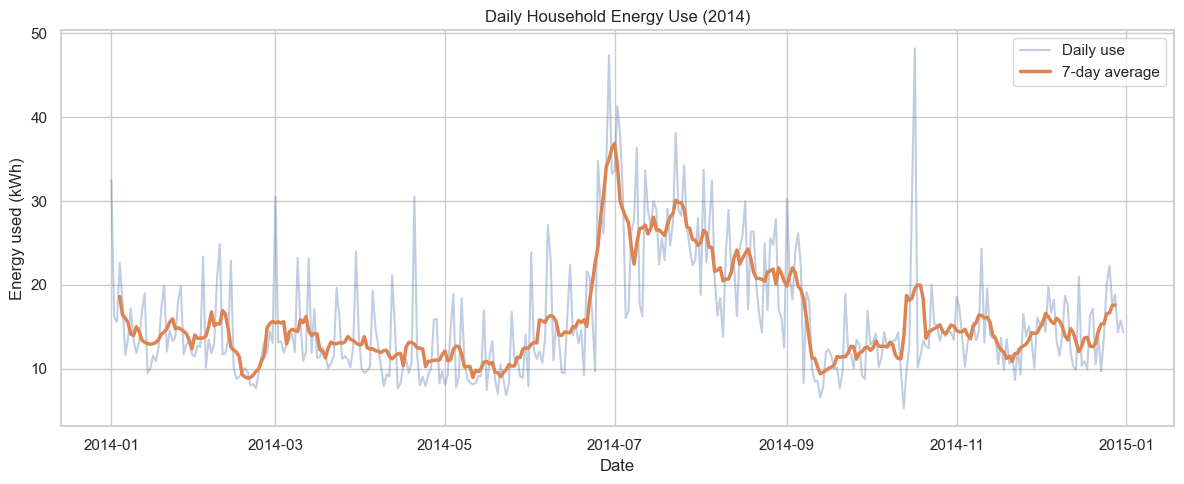

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eda_df["date"], eda_df["total_use_kWh"], alpha=0.35, label="Daily use")
ax.plot(eda_df["date"], eda_df["total_use_kWh"].rolling(7, center=True).mean(),
        linewidth=2.5, label="7-day average")
ax.set_title("Daily Household Energy Use (2014)")
ax.set_xlabel("Date")
ax.set_ylabel("Energy used (kWh)")
ax.legend()
plt.tight_layout()
plt.show()

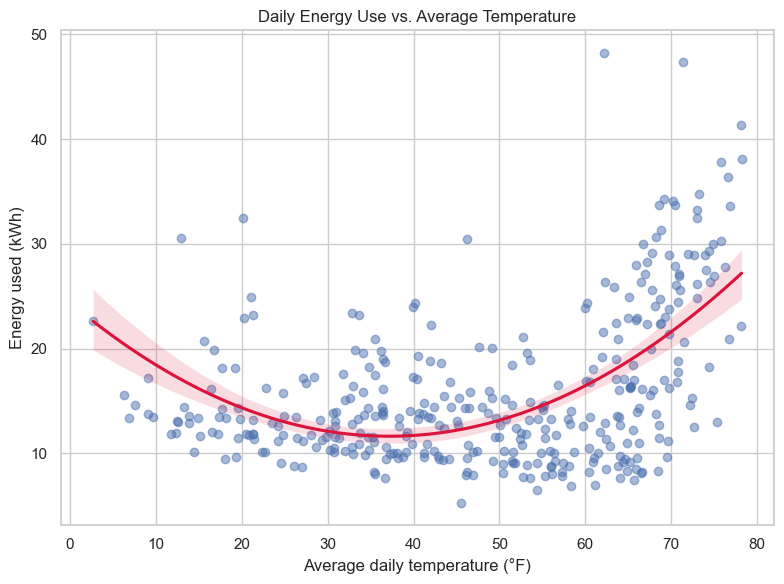

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=eda_df, x="temperature", y="total_use_kWh", order=2,
            scatter_kws={"alpha": 0.5}, line_kws={"color": "crimson"}, ax=ax)
ax.set_title("Daily Energy Use vs. Average Temperature")
ax.set_xlabel("Average daily temperature (°F)")
ax.set_ylabel("Energy used (kWh)")
plt.tight_layout()
plt.show()

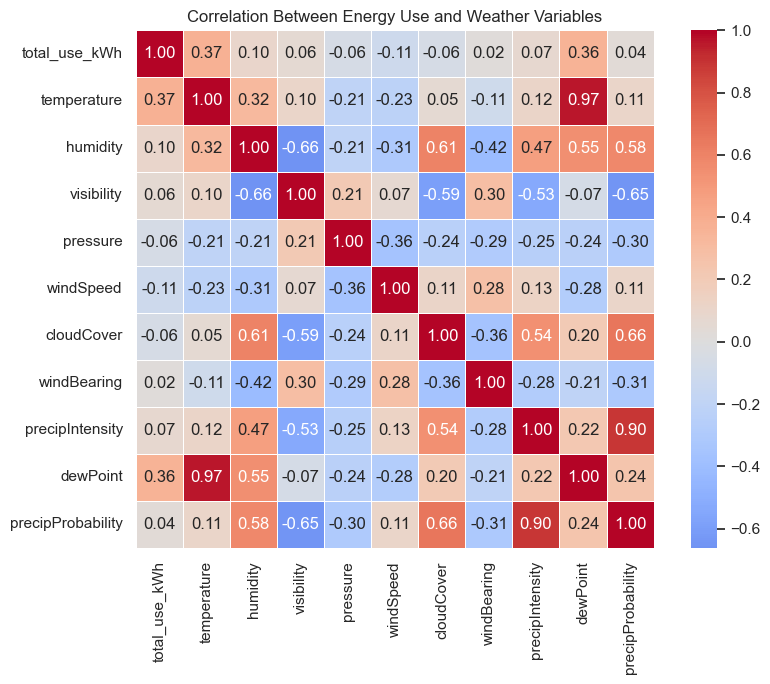

In [10]:
corr_cols = ["total_use_kWh", "temperature", "humidity", "visibility", "pressure",
             "windSpeed", "cloudCover", "windBearing", "precipIntensity",
             "dewPoint", "precipProbability"]
corr_cols = [c for c in corr_cols if c in eda_df.columns]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(eda_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Between Energy Use and Weather Variables")
plt.tight_layout()
plt.show()

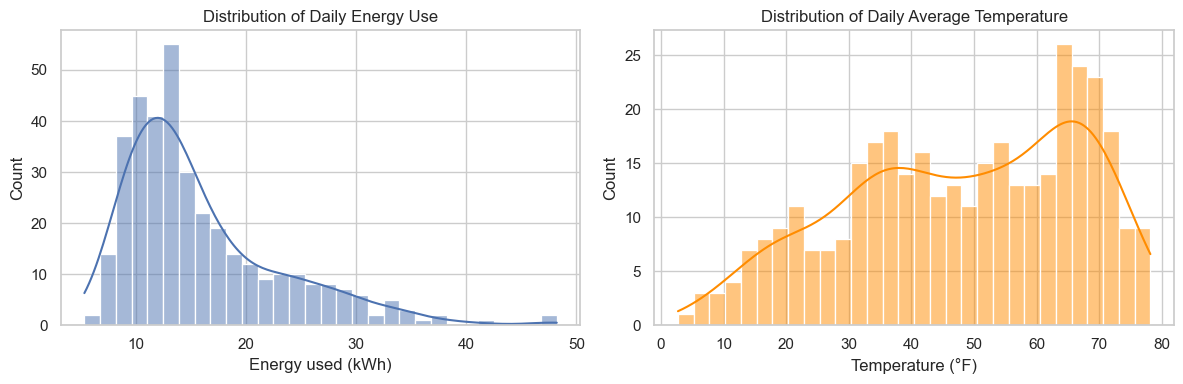

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda_df["total_use_kWh"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Daily Energy Use")
axes[0].set_xlabel("Energy used (kWh)")
sns.histplot(eda_df["temperature"], bins=30, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Distribution of Daily Average Temperature")
axes[1].set_xlabel("Temperature (°F)")
plt.tight_layout()
plt.show()

In [12]:
merged_df["date"] = pd.to_datetime(merged_df["date"])
test_df = merged_df[merged_df["date"].dt.month == 12]
train_df = merged_df[merged_df["date"].dt.month != 12]

feature_train = train_df.drop(columns=["date","total_use_kW","time"])
kw_train = train_df["total_use_kW"]

feature_test = test_df.drop(columns=["date","total_use_kW","time"])
kw_test = test_df["total_use_kW"]

print("feature_train:", feature_train.shape)
print("feature_test:", feature_test.shape)
print("kw_train:", kw_train.shape)
print("kw_test:", kw_test.shape)

feature_train: (334, 10)
feature_test: (31, 10)
kw_train: (334,)
kw_test: (31,)


In [13]:
#Convert to list
feature_train_df = feature_train.values.tolist()
feature_test_df = feature_test.values.tolist()

#Add bias column
X_train = np.array([[1] + row for row in feature_train_df]) 
X_test = np.array([[1] + row for row in feature_test_df])   
y_train = np.array(kw_train)  
y_test = np.array(kw_test)

#X^T*X
XTX = X_train.T @ X_train

#X^T*y
XTy = X_train.T @ y_train

# Compute weights (XTX)^-1 * XTy
weights = np.linalg.inv(XTX) @ XTy  

#Make predictions on test set
y_pred = X_test @ weights

#Compute RMSE
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(f"Root Mean Sqaured Error:{rmse} kW")

pred_df = pd.DataFrame({"date": test_df["date"].values,"total_use_kW": y_pred})
pred_df.to_csv("linear_regression.csv", index=False)


Root Mean Sqaured Error:8.740566311244464 kW


In [14]:
daily_weather["temp_class"] = ["high" if t >= 35 else "low" for t in daily_weather["temperature"]]

#Split into train and test sets
daily_weather["date"] = pd.to_datetime(daily_weather["date"])
train_df = daily_weather[daily_weather["date"].dt.month != 12]
test_df = daily_weather[daily_weather["date"].dt.month == 12]

X_train = train_df[["humidity", "visibility", "pressure", "windSpeed", "cloudCover", "windBearing", "precipIntensity", "dewPoint", "precipProbability"]]
X_test = test_df[["humidity", "visibility", "pressure", "windSpeed", "cloudCover", "windBearing", "precipIntensity", "dewPoint", "precipProbability"]]

# Encode labels into 0s and 1s
label_map = {"low": 0, "high": 1}
y_train = train_df["temp_class"].map(label_map).values
y_test = test_df["temp_class"].map(label_map).values

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

#Calculate mean and std of training data
feature_means = X_train_np.mean(axis=0)
feature_stds = X_train_np.std(axis=0)

#Scale training data
X_train_scaled = (X_train_np - feature_means) / feature_stds

#Scale test data using training stats
X_test_scaled = (X_test_np - feature_means) / feature_stds

weights = np.zeros(X_train_scaled.shape[1])

# Perform Gradient descent
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

learning_rate = 0.2
max_iter =1000

for _ in range(max_iter):
    z = X_train_scaled @ weights
    predictions = sigmoid(z)
    errors = predictions - y_train
    gradient = X_train_scaled.T @ errors / len(y_train)
    weights -= learning_rate * gradient

# Predictions on test set
z_test = X_test_scaled @ weights
y_pred_prob = sigmoid(z_test)
y_pred = (y_pred_prob >= 0.3).astype(int)
#Calculating F1 score
TP = 0
FP = 0
TN = 0
FN = 0
for true, pred in zip(y_test, y_pred):
    if true == 1 and pred == 1:
        TP += 1
    elif true == 0 and pred == 1:
        FP += 1
    elif true == 0 and pred == 0:
        TN += 1
    elif true == 1 and pred == 0:
        FN += 1

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"F1 Score: {f1}" )
print(f"TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")

prediction_df = pd.DataFrame({
    "date": test_df["date"].values,
    "predicted_class": y_pred
})
prediction_df.to_csv("logistic_regression.csv", index=False)


F1 Score: 0.7272727272727274
TP: 8, FP: 1, TN: 17, FN: 5


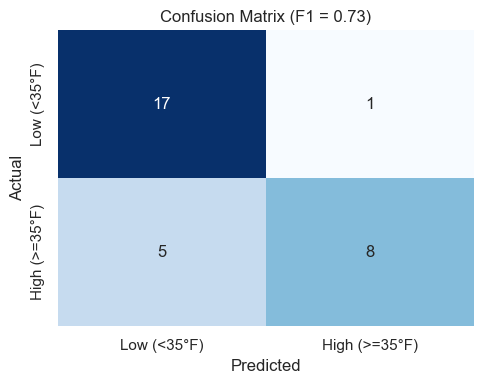

In [15]:
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Low (<35°F)", "High (>=35°F)"],
            yticklabels=["Low (<35°F)", "High (>=35°F)"], ax=ax)
ax.set_title(f"Confusion Matrix (F1 = {f1:.2f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

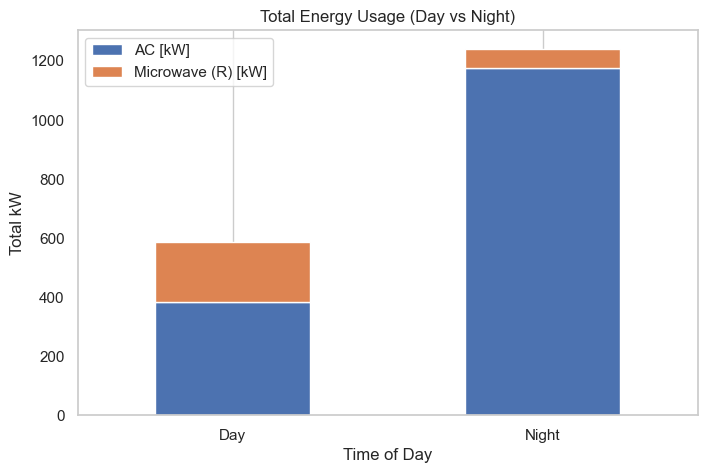

In [16]:
# Convert to datetime
edf["Date & Time"] = pd.to_datetime(edf["Date & Time"])
edf["hour"] = edf["Date & Time"].dt.hour
edf["date"] = edf["Date & Time"].dt.date

# Label time period with Day and Night
edf["period"] = np.where((edf["hour"] >= 6) & (edf["hour"] < 19), "Day", "Night")

# Group by period and sum AC and Microwave energy usage
usage_summary = edf.groupby("period")[["AC [kW]", "Microwave (R) [kW]"]].sum().reset_index()

# Stacked bar chart
usage_summary.set_index("period").plot(kind="bar", figsize=(8, 5), stacked = "True")
plt.title("Total Energy Usage (Day vs Night)")
plt.ylabel("Total kW")
plt.xlabel("Time of Day")
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

#AC is used way more at night than in the day, one of the reason likley due to 
#more people being at home during that time. 
#The microwave is used a lot more during the day, one of the reason likley being people eat more during the day.

In [17]:
edf["month"] = edf["Date & Time"].dt.month
edf["is_weekend"] = edf["Date & Time"].dt.dayofweek >= 5

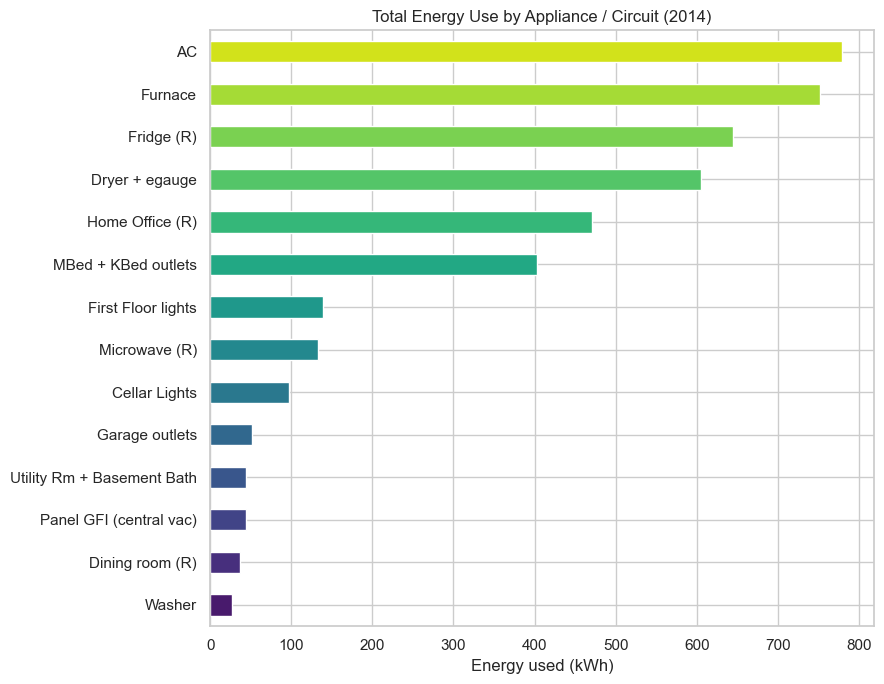

In [18]:
exclude = ["use [kW]", "gen [kW]", "Grid [kW]"]
appliance_cols = [c for c in edf.columns if c.endswith("[kW]") and c not in exclude]

appliance_kwh = (edf[appliance_cols].sum() * 0.5).sort_values()   # 30-min readings -> kWh
appliance_kwh.index = [c.replace(" [kW]", "") for c in appliance_kwh.index]

fig, ax = plt.subplots(figsize=(9, 7))
appliance_kwh.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(appliance_kwh)))
ax.set_title("Total Energy Use by Appliance / Circuit (2014)")
ax.set_xlabel("Energy used (kWh)")
plt.tight_layout()
plt.show()

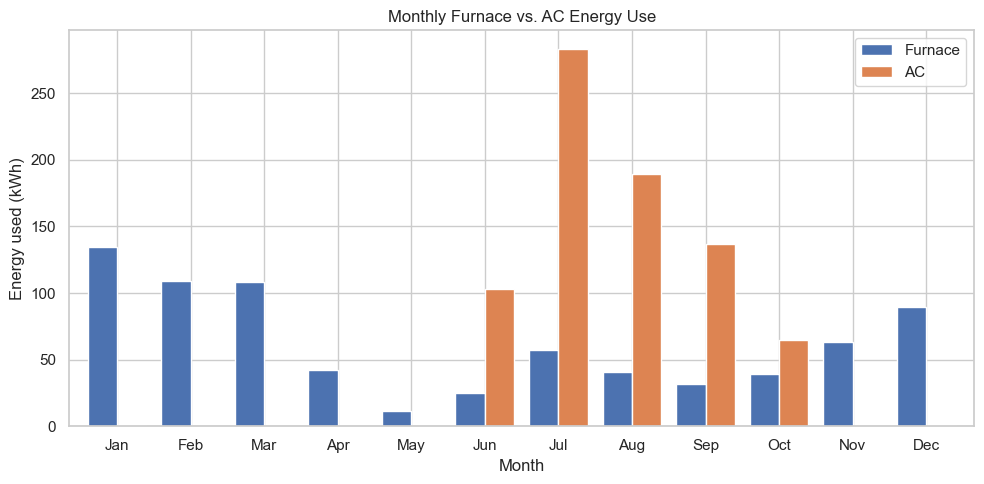

In [19]:
monthly = edf.groupby("month")[["Furnace [kW]", "AC [kW]"]].sum() * 0.5
monthly.columns = ["Furnace", "AC"]

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Monthly Furnace vs. AC Energy Use")
ax.set_xlabel("Month")
ax.set_ylabel("Energy used (kWh)")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
plt.tight_layout()
plt.show()

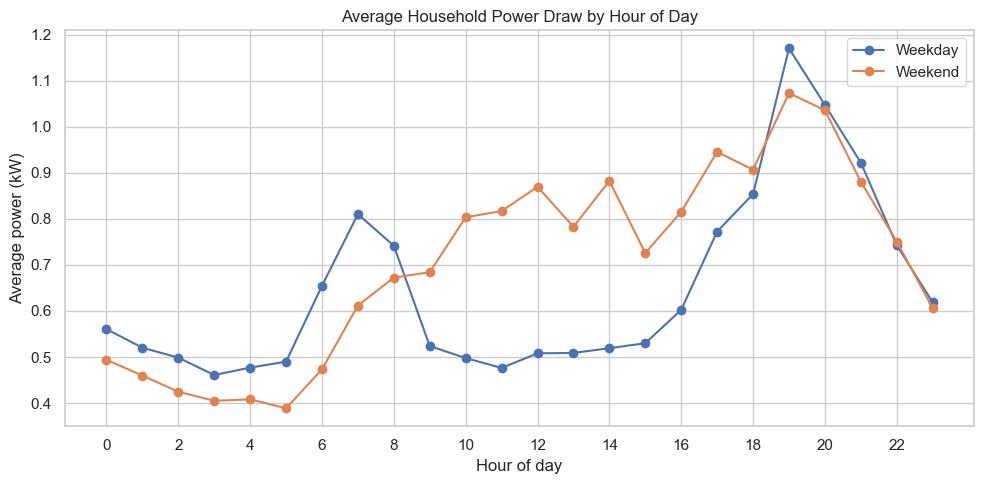

In [20]:
profile = edf.groupby(["hour", "is_weekend"])["use [kW]"].mean().unstack()
profile.columns = ["Weekday", "Weekend"]

fig, ax = plt.subplots(figsize=(10, 5))
profile.plot(ax=ax, marker="o")
ax.set_title("Average Household Power Draw by Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average power (kW)")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

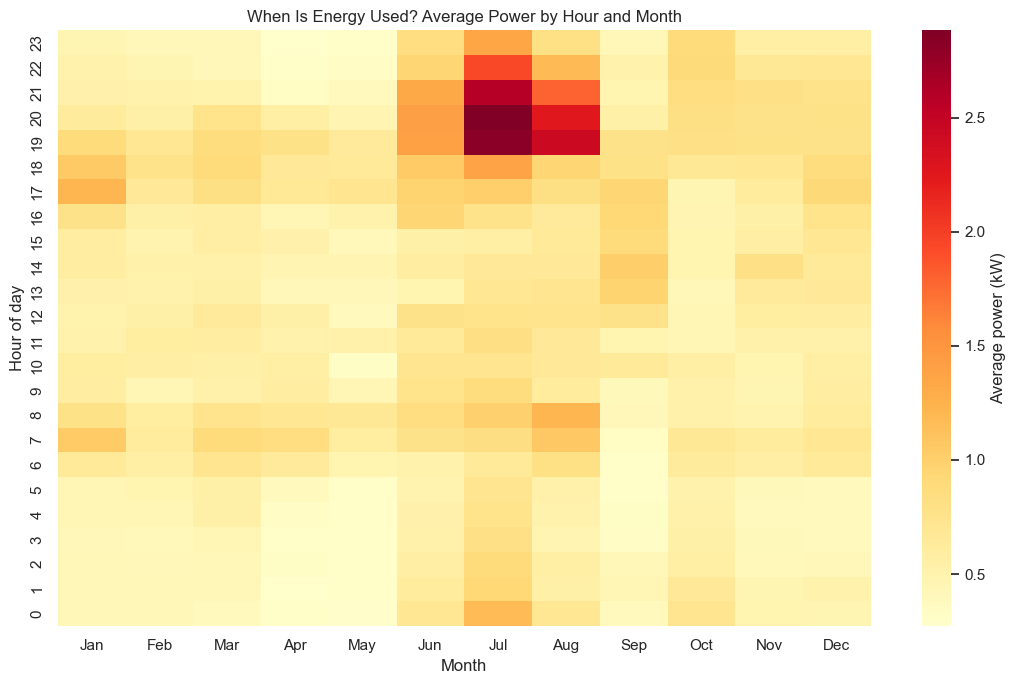

In [21]:
heat = edf.pivot_table(index="hour", columns="month", values="use [kW]", aggfunc="mean")
heat.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][:len(heat.columns)]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(heat, cmap="YlOrRd", cbar_kws={"label": "Average power (kW)"}, ax=ax)
ax.invert_yaxis()
ax.set_title("When Is Energy Used? Average Power by Hour and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of day")
plt.tight_layout()
plt.show()